# Experiment No. 7

# Comparison of Different Regression Algorithms for Predictive Modeling

## Aim

To compare the performance of different **regression algorithms** on a dataset and identify the most suitable model for accurate prediction.

## Objectives

1. Understand the working of different regression algorithms.
2. Apply multiple regression models to the same dataset.
3. Evaluate models using **MAE, MSE, RMSE, and R² Score**.
4. Compare the performance of different models.
5. Identify the best-performing model for the given dataset.

## Theory

**Linear Regression:** Models a linear relationship between input features and a continuous target.

**Polynomial Regression:** Extends linear regression by adding polynomial feature combinations to model nonlinear relationships.

**Decision Tree Regression:** Predicts continuous values by recursively splitting data using feature-based rules.

**Random Forest Regression:** Combines predictions from multiple Decision Trees to improve stability and generalization.

**Support Vector Regression (SVR):** Finds a function that fits the data within a specified error margin.

**Important:** Feature scaling is especially important for **SVR**, while tree-based models generally do not require scaling.

## Evaluation Metrics

**MAE:** Mean Absolute Error

**MSE:** Mean Squared Error

**RMSE:** Root Mean Squared Error

**R² Score:** Measures how much variation in the target is explained by the model.

For MAE, MSE and RMSE, **lower is better**.

For R² Score, **higher is generally better**.

## Implementation

1. Import libraries.
2. Load the California Housing dataset.
3. Explore and visualize the data.
4. Split the dataset.
5. Apply required preprocessing.
6. Train different regression models.
7. Evaluate each model.
8. Compare the results.
9. Visualize model performance.
10. Predict a new sample.

# Step 1 - Import Required Libraries

We import the libraries required for data processing, visualization, regression algorithms, preprocessing, and evaluation.

In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2 - Load the California Housing Dataset

The **California Housing dataset** is a regression dataset containing information about housing districts in California.

The target variable represents the median house value.

In [33]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = pd.Series(
    housing.target,
    name="MedHouseVal"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Step 3 - Display the Dataset

The `head()` function displays the first five records to understand the structure of the dataset.

In [34]:
print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Target:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

# Step 4 - Check Dataset Shape

We check the number of rows and columns present in the dataset.

In [35]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 20640
Number of features: 8


# Step 5 - Display Feature Names

The dataset contains eight input features related to housing and population characteristics.

In [36]:
print("Feature Names:")

for feature in X.columns:
    print("-", feature)

Feature Names:
- MedInc
- HouseAge
- AveRooms
- AveBedrms
- Population
- AveOccup
- Latitude
- Longitude


# Step 6 - Check Missing Values

Missing values can affect regression models, so we check whether any feature contains missing observations.

In [37]:
print("Missing values in each feature:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in each feature:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Missing values in target:
0


# Step 7 - Statistical Summary

The `describe()` function provides statistical information such as mean, standard deviation, minimum, maximum, and quartiles.

In [38]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


# Step 8 - Visualize Target Distribution

We visualize the distribution of the target variable to understand how house values are distributed.

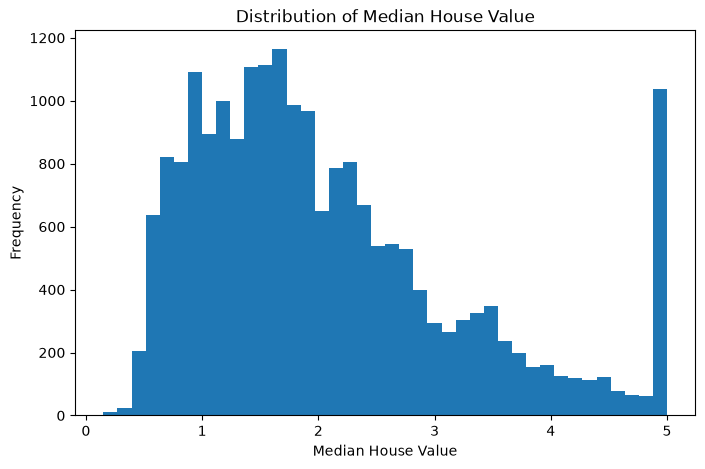

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=40)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

# Step 9 - Analyze Feature Correlations

A correlation matrix helps us understand the linear relationship between features and the target variable.

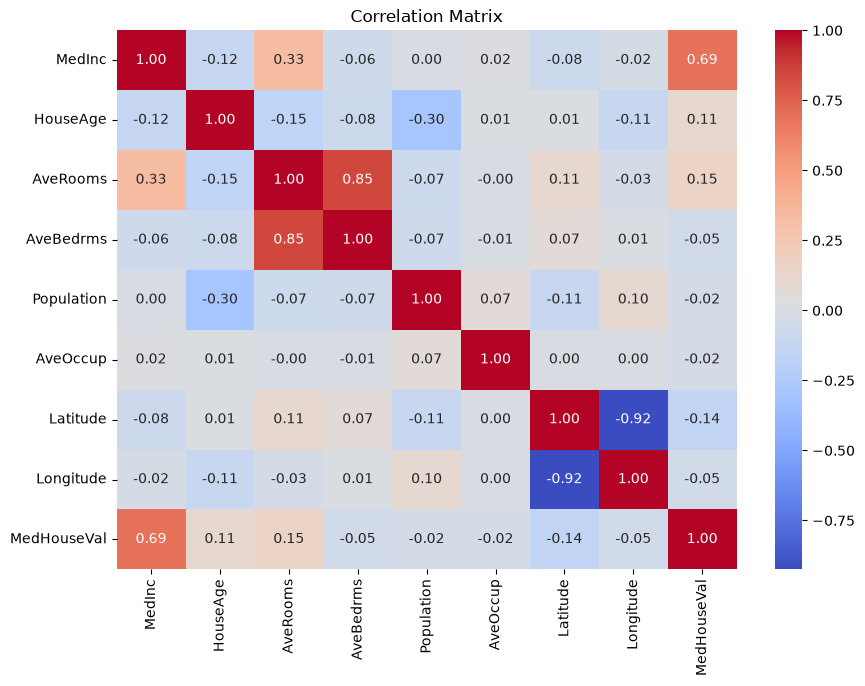

In [40]:
correlation_data = X.copy()
correlation_data["MedHouseVal"] = y

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Step 10 - Visualize Important Feature Relationship

We visualize the relationship between **Median Income** and the target variable.

This helps us understand whether an important feature has a visible relationship with house value.

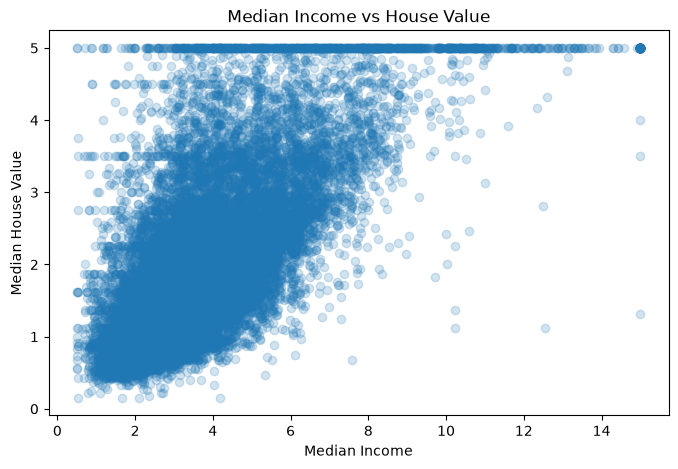

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.2
)

plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

# Step 11 - Split Dataset into Training and Testing Sets

The dataset is divided into:

- **80% training data**
- **20% testing data**

The training data is used to train the models, while the testing data is used to evaluate their performance on unseen data.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


# Step 12 - Standardize Features

Feature scaling is especially important for **SVR** because it is sensitive to feature magnitudes.

We fit the scaler only on the training data and then transform both training and testing data.

In [43]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Step 13 - Scale Target Variable for SVR

The target variable is also standardized for SVR.

After prediction, the values will be converted back to the original target scale.

In [44]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

print("Target scaling completed.")

Target scaling completed.


# Step 14 - Initialize Linear Regression

Linear Regression assumes a linear relationship between the input features and the target variable.

In [45]:
linear_model = LinearRegression()

print("Linear Regression model created.")

Linear Regression model created.


# Step 15 - Train Linear Regression

The Linear Regression model is trained using the training dataset.

In [46]:
linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression training completed.")

Linear Regression training completed.


# Step 16 - Create Polynomial Regression

Polynomial Regression adds polynomial combinations of the original features.

Here, **degree = 2** is used to capture moderate nonlinear relationships.

In [47]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

polynomial_model = LinearRegression()

print("Polynomial features created.")
print("Original number of features:", X_train.shape[1])
print("Polynomial number of features:", X_poly_train.shape[1])

Polynomial features created.
Original number of features: 8
Polynomial number of features: 44


# Step 17 - Train Polynomial Regression

The transformed polynomial features are used to train a Linear Regression model.

This allows the model to represent nonlinear relationships.

In [48]:
polynomial_model.fit(
    X_poly_train,
    y_train
)

y_pred_poly = polynomial_model.predict(
    X_poly_test
)

print("Polynomial Regression training completed.")

Polynomial Regression training completed.


# Step 18 - Train Decision Tree Regression

Decision Tree Regression predicts continuous values by recursively splitting the dataset according to feature-based conditions.

A maximum depth is used to reduce the risk of excessive tree growth.

In [49]:
decision_tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_model.predict(
    X_test
)

print("Decision Tree Regression training completed.")

Decision Tree Regression training completed.


# Step 19 - Train Random Forest Regression

Random Forest is an ensemble method that combines predictions from multiple Decision Trees.

The final prediction is based on the combined predictions of the trees.

In [50]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_forest = random_forest_model.predict(
    X_test
)

print("Random Forest Regression training completed.")

Random Forest Regression training completed.


# Step 20 - Train Support Vector Regression (SVR)

SVR is the regression version of Support Vector Machine.

The **RBF kernel** is used to model nonlinear relationships.

Because SVR is sensitive to feature scale, standardized features are used.

In [51]:
svr_model = SVR(
    kernel="rbf",
    C=10,
    gamma="scale",
    epsilon=0.1
)

svr_model.fit(
    X_train_scaled,
    y_train_scaled
)

y_pred_svr_scaled = svr_model.predict(
    X_test_scaled
)

y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

print("SVR training completed.")

SVR training completed.


# Step 21 - Define Evaluation Function

We create a function to calculate the main regression metrics:

- **MAE**
- **MSE**
- **RMSE**
- **R² Score**

In [52]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

print("Evaluation function created.")

Evaluation function created.


# Step 22 - Evaluate All Regression Models

Each trained model is evaluated using the same test dataset.

This allows a fair comparison of their predictive performance.

In [53]:
results = {}

results["Linear Regression"] = evaluate_model(
    y_test,
    y_pred_linear
)

results["Polynomial Regression"] = evaluate_model(
    y_test,
    y_pred_poly
)

results["Decision Tree Regression"] = evaluate_model(
    y_test,
    y_pred_tree
)

results["Random Forest Regression"] = evaluate_model(
    y_test,
    y_pred_forest
)

results["SVR"] = evaluate_model(
    y_test,
    y_pred_svr
)

results_df = pd.DataFrame(results).T

results_df

,MAE,MSE,RMSE,R2 Score
Linear Regression,0.533200,0.555892,0.745581,0.575788
Polynomial Regression,0.467001,0.464302,0.681397,0.645682
Decision Tree Regression,0.433203,0.415468,0.644568,0.682948
Random Forest Regression,0.327543,0.255368,0.505340,0.805123
SVR,0.376807,0.322227,0.567651,0.754102


# Step 23 - Display Model Performance

The results are rounded to make the comparison easier to read.

In [54]:
results_rounded = results_df.copy()

results_rounded = results_rounded.round(4)

results_rounded

,MAE,MSE,RMSE,R2 Score
Linear Regression,0.5332,0.5559,0.7456,0.5758
Polynomial Regression,0.4670,0.4643,0.6814,0.6457
Decision Tree Regression,0.4332,0.4155,0.6446,0.6829
Random Forest Regression,0.3275,0.2554,0.5053,0.8051
SVR,0.3768,0.3222,0.5677,0.7541


# Step 24 - Compare R² Scores

The **R² Score** indicates how much variation in the target variable is explained by each model.

A higher R² value generally indicates better predictive performance on the test data.

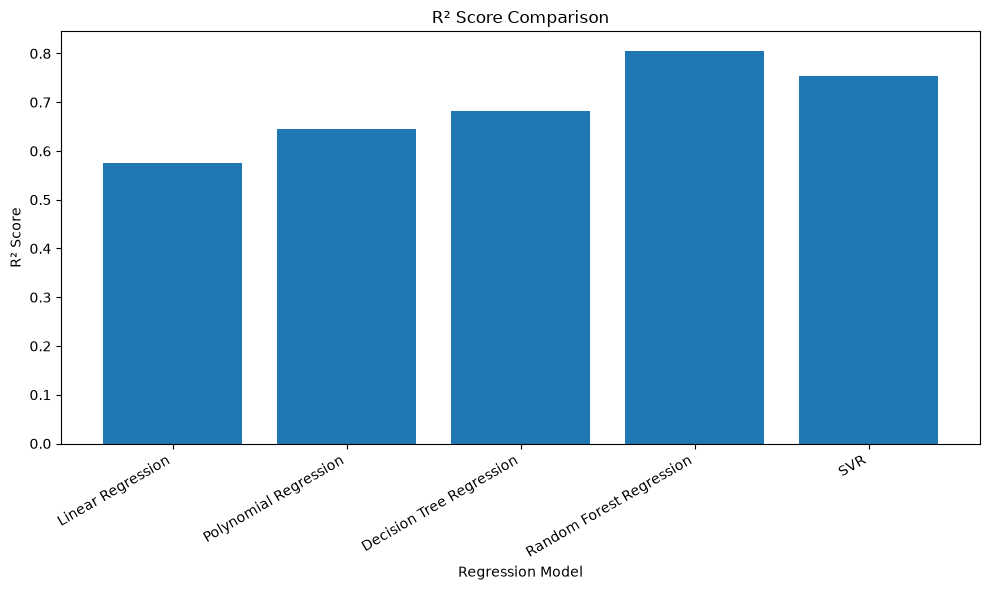

In [55]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df.index,
    results_df["R2 Score"]
)

plt.title("R² Score Comparison")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

# Step 25 - Compare RMSE

**RMSE (Root Mean Squared Error)** measures the typical magnitude of prediction errors.

A lower RMSE indicates better performance.

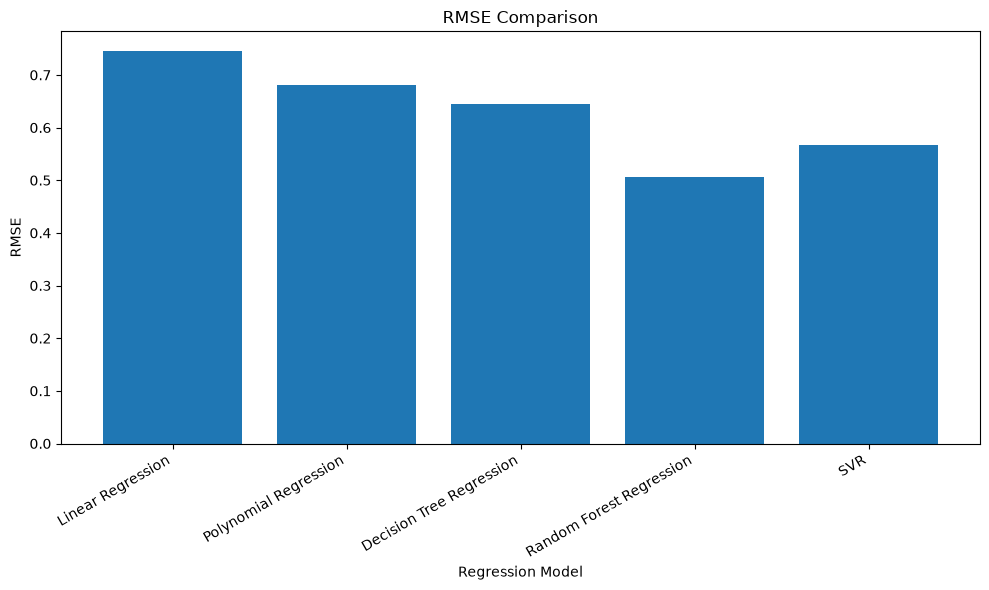

In [56]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df.index,
    results_df["RMSE"]
)

plt.title("RMSE Comparison")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

# Step 26 - Actual vs Predicted Values

We compare actual target values with predictions from the Random Forest model.

Points closer to the diagonal relationship indicate better predictions.

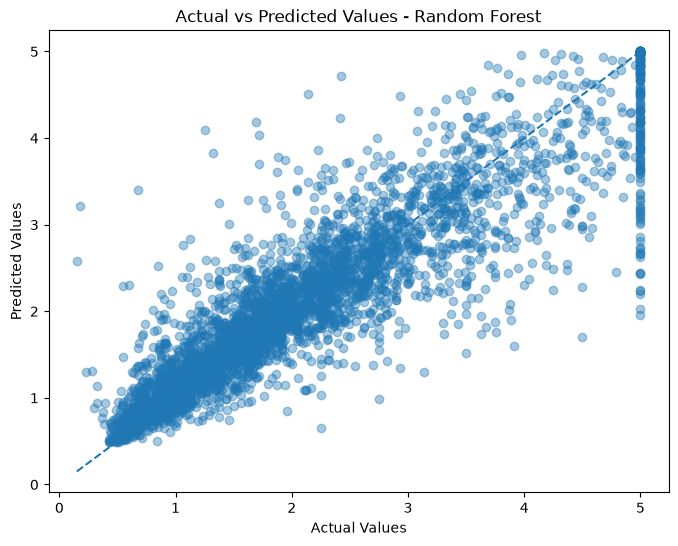

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_forest,
    alpha=0.4
)

min_value = min(y_test.min(), y_pred_forest.min())
max_value = max(y_test.max(), y_pred_forest.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Values - Random Forest")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

# Step 27 - Analyze Prediction Residuals

A residual is the difference between the actual and predicted value.

$$
Residual = Actual - Predicted
$$

A residual plot helps us identify patterns in prediction errors.

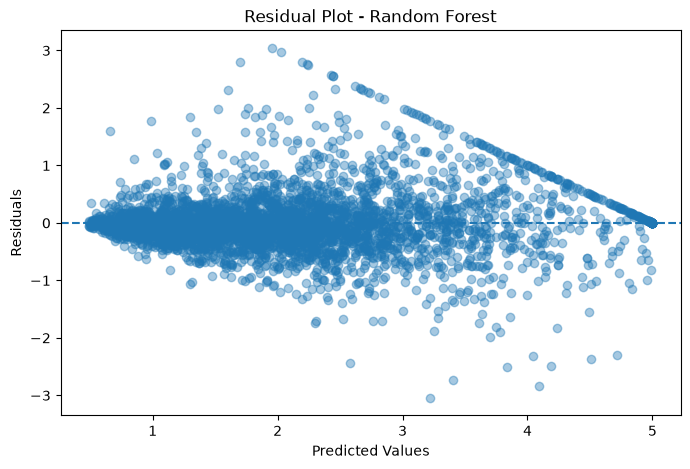

In [58]:
residuals = y_test - y_pred_forest

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_forest,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

# Step 28 - Cross-Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple training and validation splits.

Here, **5-fold cross-validation** is used for the regression models.

In [59]:
models_for_cv = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = {}

for name, model in models_for_cv.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

print("Average 5-Fold Cross-Validation R² Scores:")

for name, score in cv_results.items():
    print(
        f"{name}: {score:.4f}"
    )

Average 5-Fold Cross-Validation R² Scores:
Linear Regression: 0.5530
Decision Tree: 0.4744
Random Forest: 0.6561


# Step 29 - Identify the Best Performing Model

For this experiment, we identify the model with the highest **test-set R² Score**.

This conclusion applies specifically to the dataset and experimental settings used here.

In [60]:
best_model_name = results_df["R2 Score"].idxmax()
best_r2 = results_df.loc[
    best_model_name,
    "R2 Score"
]

print("Best Model based on Test R² Score:")
print(best_model_name)

print(
    "\nTest R² Score:",
    round(best_r2, 4)
)

Best Model based on Test R² Score:
Random Forest Regression

Test R² Score: 0.8051


# Step 30 - Predict a New Housing Sample

Finally, we use the trained models to predict the target value for a new housing sample.

The sample must contain the same eight features used during training.

In [61]:
# Create a new sample using the mean value of each feature
new_sample = X_train.mean().to_frame().T

# Predictions from each model
new_pred_linear = linear_model.predict(
    new_sample
)[0]

new_pred_poly = polynomial_model.predict(
    poly.transform(new_sample)
)[0]

new_pred_tree = decision_tree_model.predict(
    new_sample
)[0]

new_pred_forest = random_forest_model.predict(
    new_sample
)[0]

# Scale sample for SVR
new_sample_scaled = scaler_X.transform(
    new_sample
)

new_pred_svr_scaled = svr_model.predict(
    new_sample_scaled
)

new_pred_svr = scaler_y.inverse_transform(
    new_pred_svr_scaled.reshape(-1, 1)
)[0, 0]

print("New Sample:")
display(new_sample)

print("\nPredicted Values:")
print(
    "Linear Regression       :", round(new_pred_linear, 4)
)
print(
    "Polynomial Regression   :", round(new_pred_poly, 4)
)
print(
    "Decision Tree Regression:", round(new_pred_tree, 4)
)
print(
    "Random Forest Regression:", round(new_pred_forest, 4)
)
print(
    "SVR                     :", round(new_pred_svr, 4)
)

New Sample:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.58229



Predicted Values:
Linear Regression       : 2.0719
Polynomial Regression   : 1.9566
Decision Tree Regression: 0.9369
Random Forest Regression: 0.8529
SVR                     : 1.2519


# 📊 Final Results

The following regression algorithms were implemented and compared:

- **Linear Regression**
- **Polynomial Regression**
- **Decision Tree Regression**
- **Random Forest Regression**
- **Support Vector Regression (SVR)**

The models were evaluated using:

- **MAE**
- **MSE**
- **RMSE**
- **R² Score**

For **MAE, MSE, and RMSE**, lower values indicate lower prediction error.

For **R² Score**, a higher value generally indicates better predictive performance.

The final model selection should be based on the actual experimental results rather than assuming that one algorithm is always superior.m

# 📚 References

- Scikit-learn Documentation
- California Housing Dataset
- Python Documentation
- NumPy Documentation
- Pandas Documentation

# ✅ Conclusion

In this experiment, different regression algorithms were successfully implemented and compared on the **California Housing dataset**.

The algorithms studied were **Linear Regression, Polynomial Regression, Decision Tree Regression, Random Forest Regression, and Support Vector Regression (SVR)**.

Their performance was evaluated using **MAE, MSE, RMSE, and R² Score**.

Linear Regression is suitable when relationships are approximately linear. Polynomial Regression can model nonlinear relationships but may become complex as the polynomial degree increases. Decision Tree Regression can capture nonlinear patterns but may overfit if its complexity is not controlled. Random Forest combines multiple Decision Trees and can provide strong performance on complex datasets. SVR can model nonlinear relationships but is sensitive to feature scaling and parameter selection.

Based on the experimental results, the model with the most suitable performance can be selected for this dataset. The conclusion should be based on the **actual evaluation metrics obtained from the notebook**.